In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load the data
df = pd.read_csv('dataset/fake_job_postings.csv')

# Show the first 5 rows (Interactive Table)
display(df.head())

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Total Real Jobs: 17014
Total Fake Jobs: 866


C:\Users\BAPS\AppData\Local\Temp\ipykernel_15896\67476409.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraudulent', data=df, palette='coolwarm')


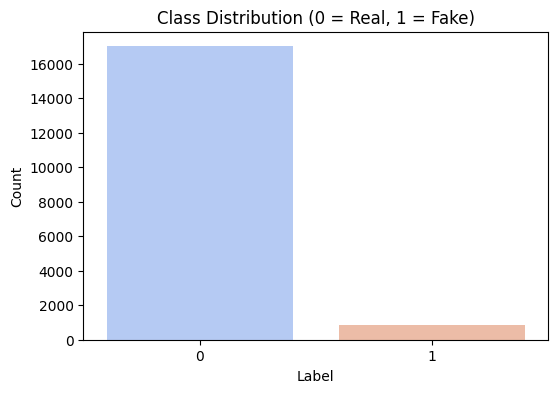

In [8]:
# Count the numbers
real_jobs = len(df[df['fraudulent'] == 0])
fake_jobs = len(df[df['fraudulent'] == 1])

print(f"Total Real Jobs: {real_jobs}")
print(f"Total Fake Jobs: {fake_jobs}")

# Visualize the Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='fraudulent', data=df, palette='coolwarm')
plt.title("Class Distribution (0 = Real, 1 = Fake)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

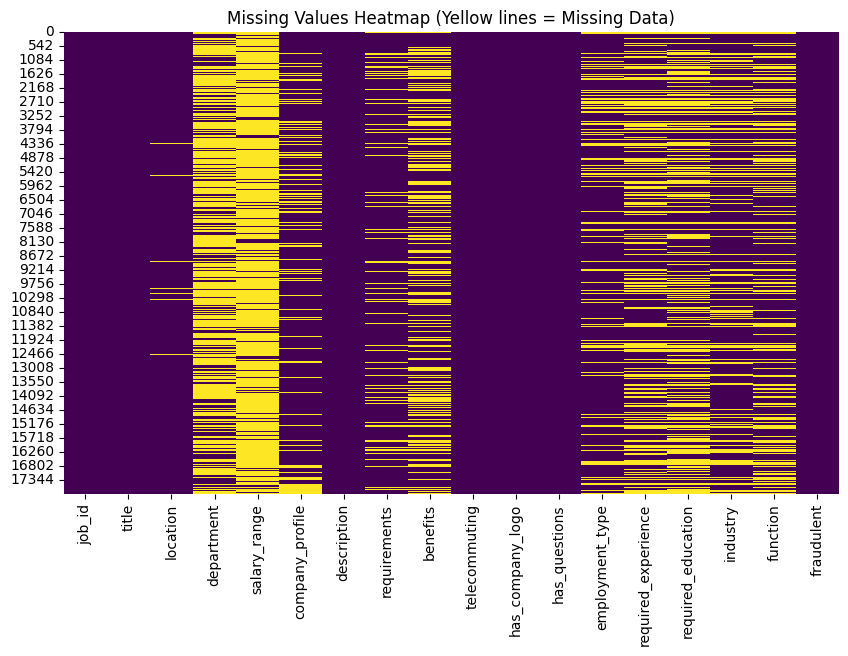

In [10]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Yellow lines = Missing Data)")
plt.show()

# Insight: You will see lots of yellow in 'salary_range' and 'department'.
# This tells us: "Do NOT use Salary as a feature, it's mostly empty!"

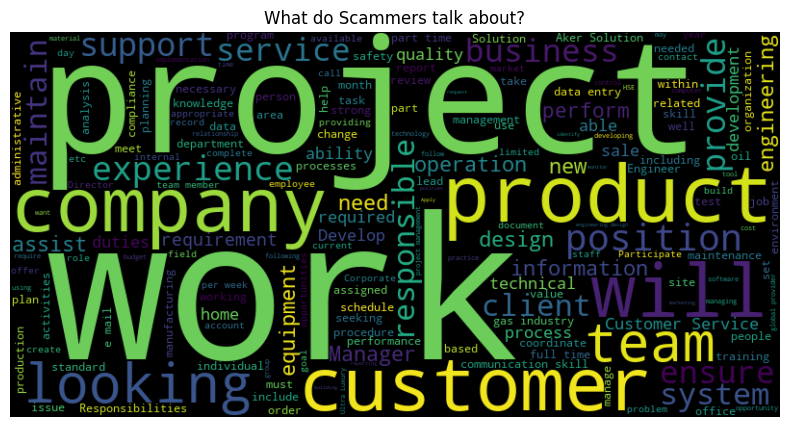

In [ ]:
# Combine all text from FAKE jobs
fake_text = " ".join(df[df['fraudulent'] == 1]['description'].fillna(''))

# Generate Cloud
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(fake_text)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("What do Scammers talk about?")
plt.show()

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data (Run this once)
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_advanced(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Convert to lower case
    text = text.lower()

    # 2. Remove URLs (http://...) and Emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)

    # 3. Remove weird symbols (Keep only letters)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenize & Lemmatize (The "Deep" Cleaning)
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(cleaned_words)

print("Cleaning 18,000 job descriptions... Please wait.")
df['text'] = df['title'] + " " + df['description'] + " " + df['requirements']
df['cleaned_text'] = df['text'].apply(clean_text_advanced)

print("Data Cleaning Complete!")
# Show the difference
display(df[['text', 'cleaned_text']].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\BAPS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\BAPS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\BAPS\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cleaning 18,000 job descriptions... Please wait.
Data Cleaning Complete!


,text,cleaned_text
0,"Marketing Intern Food52, a fast-growing, James...",marketing intern food fastgrowing james beard ...
1,Customer Service - Cloud Video Production Orga...,customer service cloud video production organi...
2,Commissioning Machinery Assistant (CMA) Our cl...,commissioning machinery assistant cma client l...
3,Account Executive - Washington DC THE COMPANY:...,account executive washington dc company esri e...
4,Bill Review Manager JOB TITLE: Itemization Rev...,bill review manager job title itemization revi...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Convert Text -> Numbers (TF-IDF)
print("Vectorizing Text...")
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['cleaned_text'])
y = df['fraudulent']

# 2. Apply SMOTE
# This creates new FAKE examples until Real == Fake

print("Applying SMOTE (Generating Synthetic Scams)...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"New Class Distribution: {Counter(y_resampled)}")


Vectorizing Text...
Applying SMOTE (Generating Synthetic Scams)...
New Class Distribution: Counter({0: 17014, 1: 17014})


Splitting data...
Applying SMOTE to Training Set...
Training Class Balance: Counter({0: 13619, 1: 13619})
Starting Grid Search (This will take a few minutes)...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  26.5s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  26.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time=  26.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=  52.3s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=  52.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=200; total time=  49.8s
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=  23.8s
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=  24.3s
[CV] END max_depth=None, min_samples_split=5, n_estimators=100; total time=  27.9s
[CV] END max_depth=None, min_sam

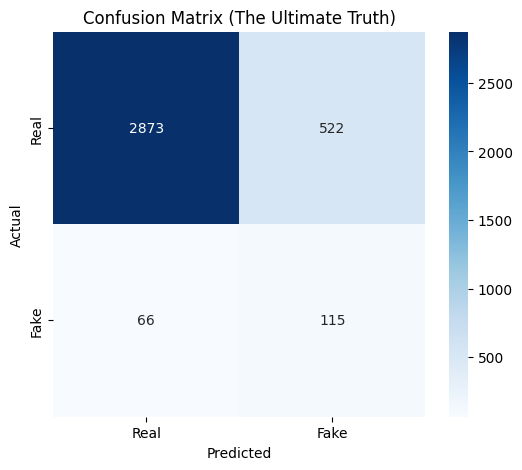

Saving the Advanced Model...
Advanced Model Saved Successfully!


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import joblib

# 1. Split the ORIGINAL data (Before SMOTE) to keep the Test Set "Pure"
# We go back to 'X' (The TF-IDF data) and 'y' (The original labels)
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Apply SMOTE *ONLY* to the Training Data
# (We teach the student with synthetic examples, but test them on real exams)
print("Applying SMOTE to Training Set...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Training Class Balance: {Counter(y_train_resampled)}")

# 3. Define the "Hyperparameter Grid" (The Settings to Test)
# We will test 2 different tree quantities and 2 differeny depths.
# (In real life, this list is huge. We keep it small to finish in ~5 mins)
param_grid = {
    'n_estimators': [100, 200],  # Try 100 trees, then 200 trees
    'max_depth': [None, 30],     # Try unlimited depth vs limited depth
    'min_samples_split': [2, 5]  # Minimum samples required to split a node
}

# 4. Initialize GridSearchCV
# cv=3 means "Cross Validation": It splits data into 3 parts and rotates them to double-check results.
print("Starting Grid Search (This will take a few minutes)...")
rf = RandomForestClassifier(random_state=42, n_jobs=1)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, verbose=2, n_jobs=1)

# 5. Train!
grid_search.fit(X_train_resampled, y_train_resampled)

print("------------------------------------------------")
print(f"BEST PARAMETERS FOUND: {grid_search.best_params_}")
print("------------------------------------------------")

# 6. Evaluate on the PURE Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 7. Visual Proof: The Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (The Ultimate Truth)')
plt.show()

# 8. Save the Upgrade
print("Saving the Advanced Model...")
# We save BOTH the vectorizer and the model, or just the pipeline components
# Ideally, we should recreate the pipeline, but for now let's save the model.
joblib.dump(best_model, 'models/jobguard_advanced_model.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')   # We need to save the translator too!
print("Advanced Model Saved Successfully!")


In [ ]:
from sklearn.metrics import precision_recall_curve

# 1. Get the raw probabilities (Confidence Scores) instead of just Yes/No
# This returns a list like [0.12, 0.45, 0.99, 0.85...]
y_probs = best_model.predict_proba(X_test)[:,1]

# 2. Calculate Precision & Recall for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label="Precison (Purity)", color="blue")
plt.plot(thresholds, recalls[:-1], label="Recall (Catch Rate)", color="green")
plt.xlabel("Threshold (Confidence Bar)")
plt.ylabel("Score")
plt.title("Precision vs Recall Trade-off")
plt.legend()
plt.grid(True)
plt.show()

# 4. Let's try a Custom Threshold (e.g., 0.75 instead of 0.5)
# You can change this number '0.75' to see how the matrix changes!
NEW_THRESHOLD = 0.6

y_pred_new = (y_probs >= NEW_THRESHOLD).astype(int)

print(f"--- RESULTS WITH NEW THRESHOLD: {NEW_THRESHOLD} ---")
print(classification_report(y_test, y_pred_new))

# Visual Proof
cm_new = confusion_matrix(y_test, y_pred_new)
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title(f'Confusion Matrix (Threshold > {NEW_THRESHOLD})')
plt.show()

NameError: name 'best_model' is not defined